# ADA Semester Project

This represents the project for the CS-401 course at EPFL, done by:

| SCIPER                                              | Name                      |
|:----------------------------------------------------|:--------------------------|
| [356420](https://people.epfl.ch/badr.almahouri)     | Badr Al Mahouri           |
| [341237](https://people.epfl.ch/louis.grange)       | Louis Grange              |
| [340497](https://people.epfl.ch/daniel.alvesataide) | Daniel Ataíde             |
| [329310](https://people.epfl.ch/arnaud.tadic)       | Arnaud Jacques Yves Tadic |
| [308396](https://people.epfl.ch/yuri.cho)           | Yuri Cho                  |

## Install dependencies

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import math
#load the statistical libraries
from statsmodels.stats import diagnostic
from scipy import stats

## Import dataset

We can first import the data from the downloaded dataset, and format it into a correct Pandas Dataframe. If you didn't download it, just do it [here](https://snap.stanford.edu/data/soc-RedditHyperlinks.html).

In [73]:
import src.utils as utils
from src.preprocessing import features

In [74]:
body_data, title_data, subreddits_data, users_data = utils.load_data()

In [75]:
print("Number of data entries")
print(f"title: {len(title_data)}, body: {len(body_data)}, subreddits: {len(subreddits_data)}, users: {len(users_data)}")

Number of data entries
title: 571927, body: 286561, subreddits: 51277, users: 118380


In [76]:
len(features), features[:10]

(86,
 ['Number of characters',
  'Number of characters without counting white space',
  'Fraction of alphabetical characters',
  'Fraction of digits',
  'Fraction of uppercase characters',
  'Fraction of white spaces',
  'Fraction of special characters (e.g., comma, exclamation mark, etc.)',
  'Number of words',
  'Number of unique words',
  'Number of long words (at least 6 characters)'])

and then check if the data has been correctly imported and formatted

In [77]:
title_data_features = title_data["PROPERTIES"].apply(lambda s: [float(x) for x in s.split(",")])

# Create a new DataFrame with features as columns
features_df = pd.DataFrame(title_data_features.tolist(), columns=features, index=title_data.index)

# Merge back into original DataFrame (drop old PROPERTIES if not needed)
title_data_expanded = pd.concat([title_data.drop(columns=["PROPERTIES"]), features_df], axis=1)

In [78]:
title_data_expanded.head(5)

,SOURCE_SUBREDDIT,TARGET_SUBREDDIT,POST_ID,TIMESTAMP,LINK_SENTIMENT,Number of characters,Number of characters without counting white space,Fraction of alphabetical characters,Fraction of digits,Fraction of uppercase characters,...,LIWC_Achiev,LIWC_Leisure,LIWC_Home,LIWC_Money,LIWC_Relig,LIWC_Death,LIWC_Assent,LIWC_Dissent,LIWC_Nonflu,LIWC_Filler
0,rddtgaming,rddtrust,1u4pzzs,2013-12-31 16:39:18,1,25.0,23.0,0.760000,0.00,0.440000,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,xboxone,battlefield_4,1u4tmfs,2013-12-31 17:59:11,1,100.0,88.0,0.780000,0.02,0.080000,...,0.058824,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ps4,battlefield_4,1u4tmos,2013-12-31 17:59:40,1,100.0,88.0,0.780000,0.02,0.080000,...,0.058824,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,fitnesscirclejerk,leangains,1u50xfs,2013-12-31 19:01:56,1,49.0,43.0,0.775510,0.00,0.265306,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,fitnesscirclejerk,lifeprotips,1u51nps,2013-12-31 21:02:28,1,14.0,14.0,0.785714,0.00,0.428571,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [79]:
body_data_features = body_data["PROPERTIES"].apply(lambda s: [float(x) for x in s.split(",")])

# Create a new DataFrame with features as columns
features_df = pd.DataFrame(body_data_features.tolist(), columns=features, index=body_data.index)

# Merge back into original DataFrame (drop old PROPERTIES if not needed)
body_data_expanded = pd.concat([body_data.drop(columns=["PROPERTIES"]), features_df], axis=1)

In [80]:
body_data_expanded.head(5)

,SOURCE_SUBREDDIT,TARGET_SUBREDDIT,POST_ID,TIMESTAMP,LINK_SENTIMENT,Number of characters,Number of characters without counting white space,Fraction of alphabetical characters,Fraction of digits,Fraction of uppercase characters,...,LIWC_Achiev,LIWC_Leisure,LIWC_Home,LIWC_Money,LIWC_Relig,LIWC_Death,LIWC_Assent,LIWC_Dissent,LIWC_Nonflu,LIWC_Filler
0,leagueoflegends,teamredditteams,1u4nrps,2013-12-31 16:39:58,1,345.0,298.0,0.756522,0.017391,0.086957,...,0.068966,0.034483,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
1,theredlion,soccer,1u4qkd,2013-12-31 18:18:37,-1,101.0,98.0,0.742574,0.019802,0.049505,...,0.000000,0.066667,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
2,inlandempire,bikela,1u4qlzs,2014-01-01 14:54:35,1,85.0,85.0,0.752941,0.023529,0.082353,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
3,nfl,cfb,1u4sjvs,2013-12-31 17:37:55,1,1124.0,949.0,0.772242,0.001779,0.057829,...,0.031250,0.020833,0.0,0.0,0.0,0.0,0.0,0.0,0.020833,0.005208
4,playmygame,gamedev,1u4w5ss,2014-01-01 02:51:13,1,715.0,622.0,0.777622,0.006993,0.025175,...,0.016667,0.025000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.008333


In [82]:
# Check mean, max, sum of all features for a given dataframe
df = title_data_expanded
raw_rows =[]
for f in features[18:]:
    raw_rows.append((
        f, 
        round(df[f].mean(), 5), 
        round(df[f].max(), 2),
        round(df[f].sum(), 2)
    ))
features_mean_max_sum = pd.DataFrame(raw_rows, columns=["Feature", "Mean", "Max", "Sum"]).set_index("Feature")
features_mean_max_sum

,Mean,Max,Sum
Feature,,,
Positive sentiment (VADER),0.07985,0.94,45667.81
Negative sentiment (VADER),0.07275,0.95,41608.84
Compound sentiment (VADER),0.00796,1.00,4554.72
LIWC_Funct,0.27951,0.97,159856.95
LIWC_Pronoun,0.05067,0.57,28979.01
...,...,...,...
LIWC_Death,0.00262,0.60,1499.84
LIWC_Assent,0.00174,0.77,997.77
LIWC_Dissent,0.00171,0.97,978.49


## Examples of initial analysis

0.004033005267526079
Number of mentions of 'LIWC_Health': 33148


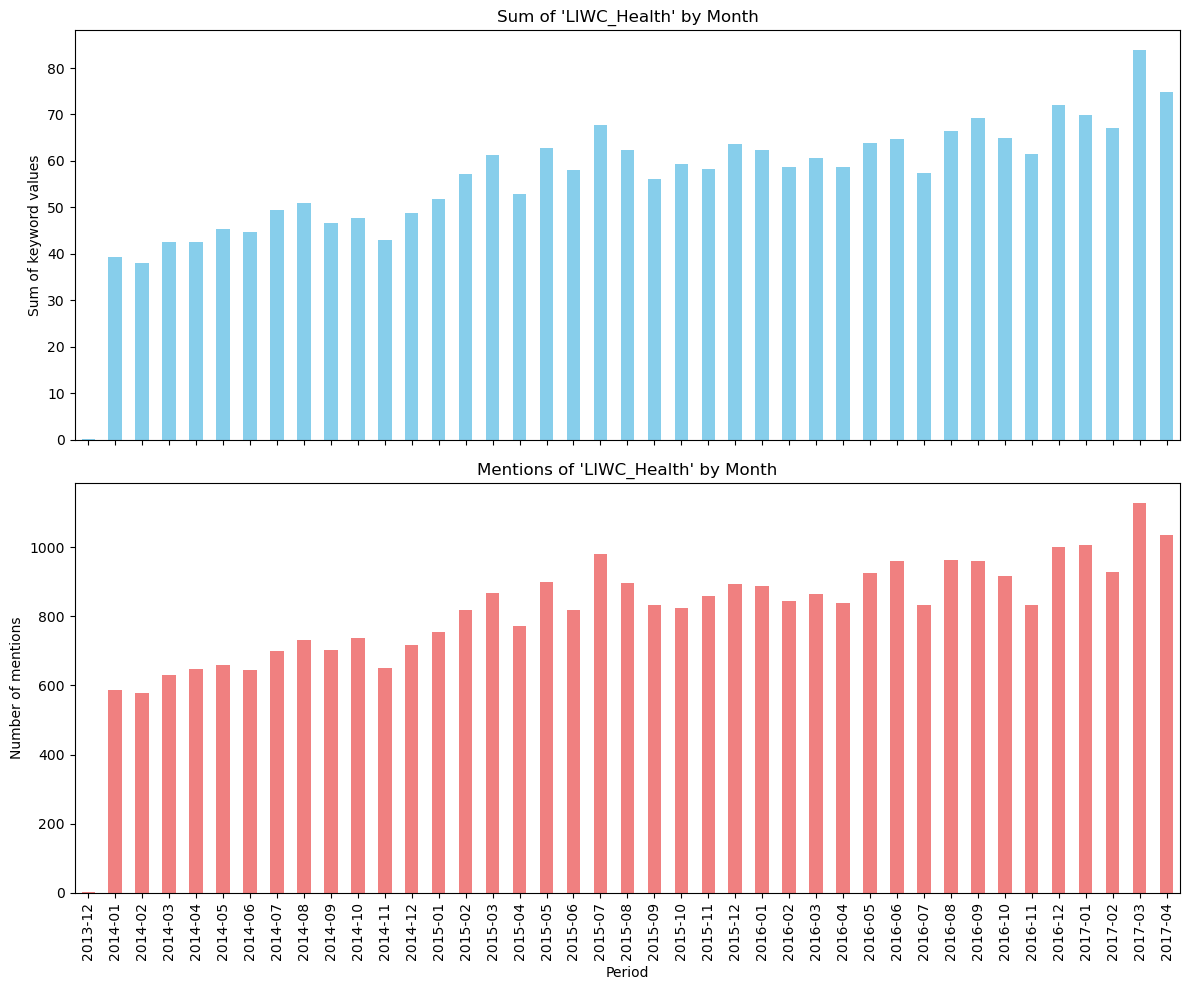

In [81]:
keyword = "LIWC_Health"
df = title_data_expanded
# df = body_data_expanded

period = "M"  # "W" for weekly, "M" for monthly aggregation

df["TIMESTAMP"] = pd.to_datetime(df["TIMESTAMP"])

print(df[keyword].mean())

sub_df = df[df[keyword] > 0]
print(f"Number of mentions of '{keyword}': {len(sub_df)}")

# Group by week or month depending on 'period'
sub_df = sub_df.assign(PERIOD=sub_df["TIMESTAMP"].dt.to_period(period))

# Sum of keyword values per period
sum_by_period = sub_df.groupby("PERIOD")[keyword].sum()

# Count of mentions per period
count_by_period = sub_df.groupby("PERIOD").size()

# Plot both on subplots
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Plot 1: Sum of keyword values
sum_by_period.plot(kind="bar", ax=axes[0], color="skyblue")
axes[0].set_title(f"Sum of '{keyword}' by {'Week' if period == 'W' else 'Month'}")
axes[0].set_ylabel("Sum of keyword values")

# Plot 2: Count of mentions
count_by_period.plot(kind="bar", ax=axes[1], color="lightcoral")
axes[1].set_title(f"Mentions of '{keyword}' by {'Week' if period == 'W' else 'Month'}")
axes[1].set_xlabel("Period")
axes[1].set_ylabel("Number of mentions")

plt.tight_layout()
plt.show()


Index(['askreddit', 'pics', 'iama', 'todayilearned', 'funny', 'worldnews',
       'videos', 'news', 'politics', 'gaming'],
      dtype='object', name='TARGET_SUBREDDIT')


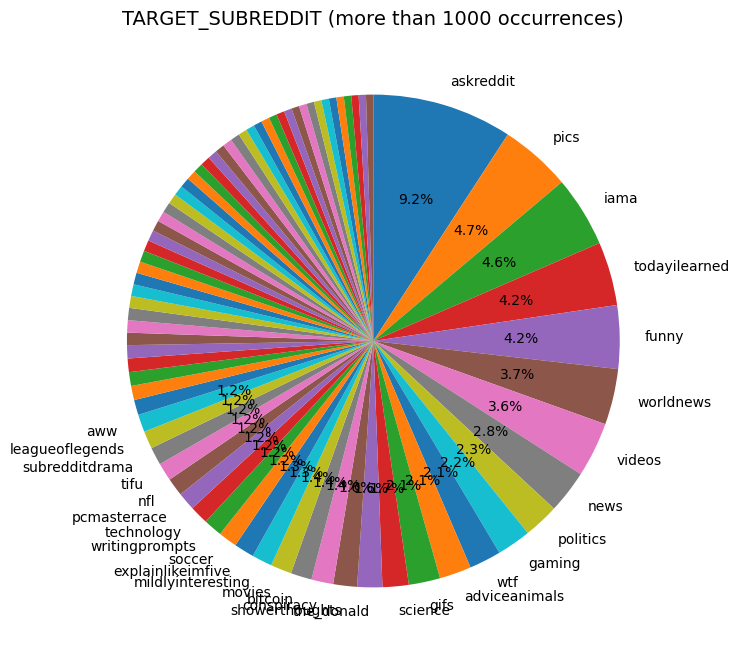

In [93]:
df = title_data_expanded
col = "TARGET_SUBREDDIT"

# Get counts
counts = df[col].value_counts()
thres = 1000

# Filter subreddits with more than threshold occurrences
counts_filtered = counts[counts > thres]

# Calculate total for percentage comparison
total = counts_filtered.sum()

cutoff = 1  # percentage cutoff
# Custom function to hide small slices in pie chart
def autopct_hide(pct):
    return f"{pct:.1f}%" if pct >= cutoff else ""

# For labels: show only if the slice is above cutoff percentage
labels = [
    label if (value / total * 100) >= cutoff else ""
    for label, value in zip(counts_filtered.index, counts_filtered)
]

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    counts_filtered,
    labels=labels,
    autopct=autopct_hide,
    startangle=90,
    counterclock=False
)
print(counts_filtered.index[:10])
plt.title(f"{col} (more than {thres} occurrences)", fontsize=14)
plt.show()

In [94]:
subreddit_list = ["apple"]
# subreddit_list = ["samsung", "apple"]

# Combine all keywords into one regex pattern
pattern = "|".join(subreddit_list)

# Add a new boolean column to each dataset
title_data_expanded["is_relevant"] = (
    title_data_expanded["SOURCE_SUBREDDIT"].str.contains(pattern, case=False, na=False) |
    title_data_expanded["TARGET_SUBREDDIT"].str.contains(pattern, case=False, na=False)
)

body_data_expanded["is_relevant"] = (
    body_data_expanded["SOURCE_SUBREDDIT"].str.contains(pattern, case=False, na=False) |
    body_data_expanded["TARGET_SUBREDDIT"].str.contains(pattern, case=False, na=False)
)

# Optional: check how many matched
print("title_data_expanded relevant count:", title_data_expanded["is_relevant"].sum())
print("body_data_expanded relevant count:", body_data_expanded["is_relevant"].sum())


title_data_expanded relevant count: 1062
body_data_expanded relevant count: 819


In [95]:
title_data_expanded[title_data_expanded["is_relevant"]].head(5)

,SOURCE_SUBREDDIT,TARGET_SUBREDDIT,POST_ID,TIMESTAMP,LINK_SENTIMENT,Number of characters,Number of characters without counting white space,Fraction of alphabetical characters,Fraction of digits,Fraction of uppercase characters,...,LIWC_Leisure,LIWC_Home,LIWC_Money,LIWC_Relig,LIWC_Death,LIWC_Assent,LIWC_Dissent,LIWC_Nonflu,LIWC_Filler,is_relevant
289,apple,jailbreak,1u8j9gs,2014-01-02 08:24:53,1,68.0,59.0,0.735294,0.014706,0.117647,...,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,True
1182,stolen,apple,1uiilhs,2013-12-31 18:45:33,1,32.0,29.0,0.781250,0.000000,0.312500,...,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,True
1391,androidcirclejerk,apple,1ukes9s,2014-01-06 13:25:12,1,83.0,70.0,0.783133,0.012048,0.096386,...,0.0,0.0,0.0,0.125,0.0,0.0,0.0,0.0,0.0,True
1624,android,apple,1umluls,2014-01-07 07:25:35,1,94.0,83.0,0.755319,0.010638,0.095745,...,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,True
1716,askengineers,apple,1unhlcs,2014-01-07 12:52:17,1,50.0,44.0,0.800000,0.000000,0.180000,...,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,True


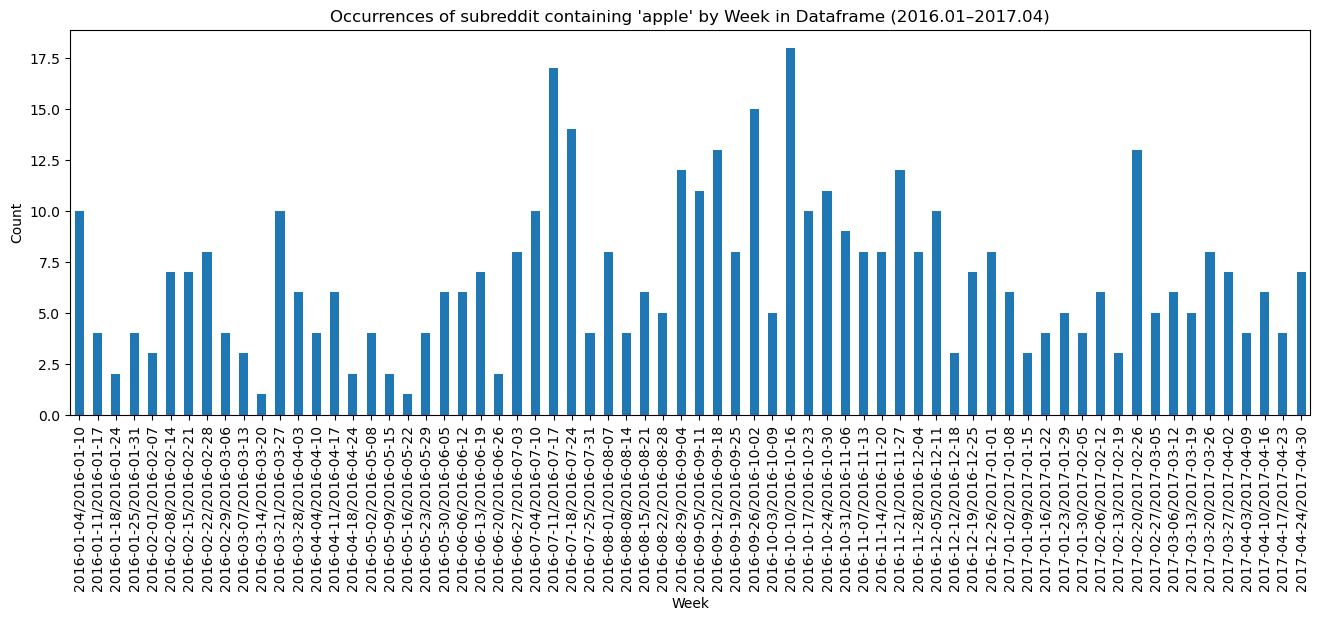

In [99]:
# Histogram of relevant mentions over time for a given dataframe
pattern = "apple"
tf = title_data_expanded

# Add a new boolean column to each dataset
tf["is_relevant"] = (
    tf["SOURCE_SUBREDDIT"].str.contains(pattern, case=False, na=False) |
    tf["TARGET_SUBREDDIT"].str.contains(pattern, case=False, na=False)
)

tf["TIMESTAMP"] = pd.to_datetime(tf["TIMESTAMP"])

# df =  title_data_expanded[title_data_expanded["is_relevant"]]
df = tf[
    (tf["is_relevant"]) 
    & (tf["TIMESTAMP"].dt.year >= 2016) 
    & (tf["TIMESTAMP"].dt.year <= 2017)
]
period = "W"

if period == "M":
    df = df.assign(MONTH=df["TIMESTAMP"].dt.to_period("M"))
    counts_by_month = df.groupby("MONTH").size()
    counts_by_month.plot(kind="bar", figsize=(12,5))
    plt.title(f"Occurrences of subreddit containing '{pattern}' by Month in Dataframe (2016.01–2017.04)")
    plt.xlabel("Month")
    
elif period == "W":
    df = df.assign(WEEK=df["TIMESTAMP"].dt.to_period("W"))
    counts_by_week = df.groupby("WEEK").size()
    counts_by_week.plot(kind="bar", figsize=(16,5))
    plt.title(f"Occurrences of subreddit containing '{pattern}' by Week in Dataframe (2016.01–2017.04)")
    plt.xlabel("Week")
    # print(counts_by_week)
plt.ylabel("Count")
plt.show()

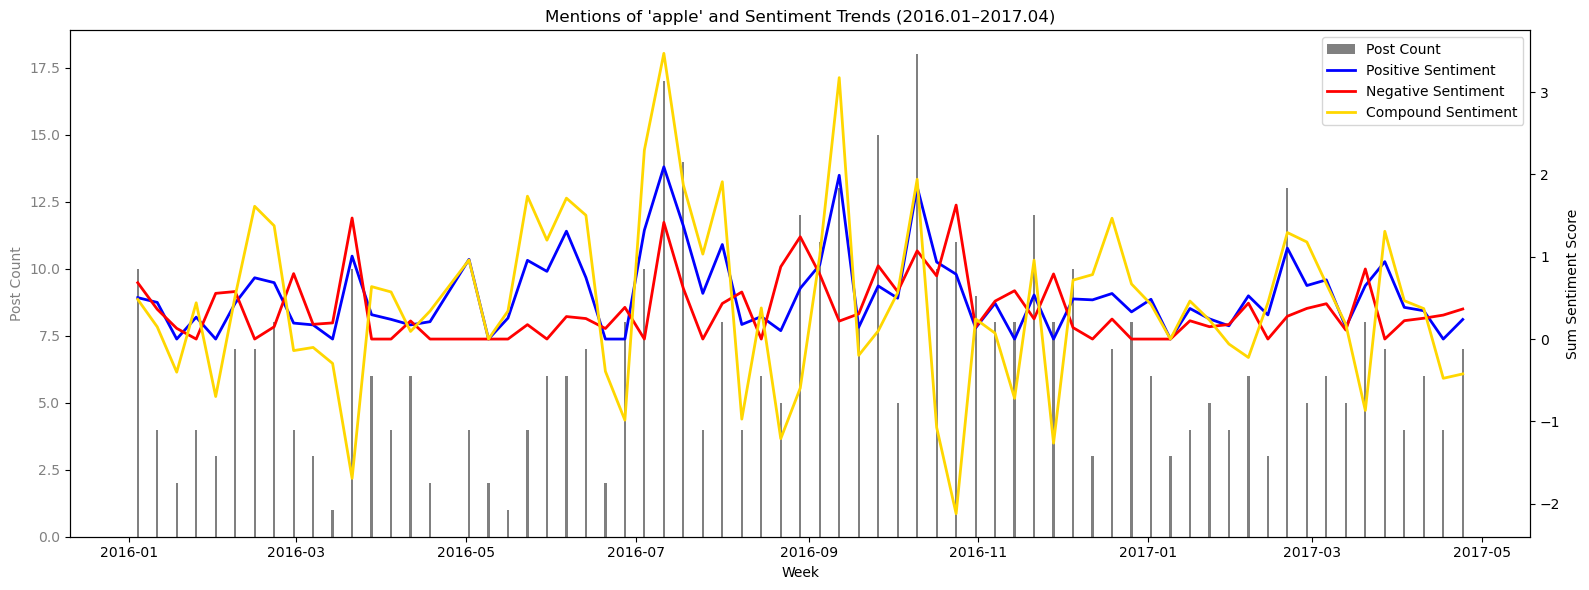

In [104]:
pattern = "apple"
tf = title_data_expanded

# Add a new boolean column to each dataset
tf["is_relevant"] = (
    tf["SOURCE_SUBREDDIT"].str.contains(pattern, case=False, na=False) |
    tf["TARGET_SUBREDDIT"].str.contains(pattern, case=False, na=False)
)

tf["TIMESTAMP"] = pd.to_datetime(tf["TIMESTAMP"])
df = tf[
    (tf["is_relevant"]) 
    & (tf["TIMESTAMP"].dt.year >= 2016) 
    & (tf["TIMESTAMP"].dt.year <= 2017)
]
# Assign weekly period
df = df.assign(WEEK=df["TIMESTAMP"].dt.to_period("W"))

# Group by week: average sentiment and count
sentiment_cols = [
    "Positive sentiment (VADER)",
    "Negative sentiment (VADER)",
    "Compound sentiment (VADER)"
]

weekly_stats = (
    df.groupby("WEEK")[sentiment_cols]
    .sum()
    .assign(Count=df.groupby("WEEK").size())
)

# Convert period index to datetime
weekly_stats.index = weekly_stats.index.to_timestamp()

# --- Plot setup ---
fig, ax1 = plt.subplots(figsize=(16,6))

# Bar plot for post count
ax1.bar(weekly_stats.index, weekly_stats["Count"], color="gray", label="Post Count")
ax1.set_ylabel("Post Count", color="gray")
ax1.set_xlabel("Week")
ax1.tick_params(axis="y", labelcolor="gray")

# Line plot for each sentiment on the second axis
ax2 = ax1.twinx()
ax2.plot(weekly_stats.index, weekly_stats["Positive sentiment (VADER)"], color="blue", label="Positive Sentiment", linewidth=2)
ax2.plot(weekly_stats.index, weekly_stats["Negative sentiment (VADER)"], color="red", label="Negative Sentiment", linewidth=2)
ax2.plot(weekly_stats.index, weekly_stats["Compound sentiment (VADER)"], color="gold", label="Compound Sentiment", linewidth=2)

ax2.set_ylabel("Sum Sentiment Score")
ax2.tick_params(axis="y")

# Title and legend
plt.title(f"Mentions of '{pattern}' and Sentiment Trends (2016.01–2017.04)")
fig.legend(loc="upper right", bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)
fig.tight_layout()
plt.show()


In [105]:
weekly_stats

,Positive sentiment (VADER),Negative sentiment (VADER),Compound sentiment (VADER),Count
WEEK,,,,
2016-01-04,0.503,0.684,0.4809,10
2016-01-11,0.445,0.362,0.1481,4
2016-01-18,0.000,0.130,-0.4019,2
2016-01-25,0.266,0.000,0.4404,4
2016-02-01,0.000,0.555,-0.6979,3
...,...,...,...,...
2017-03-27,0.940,0.000,1.3086,7
2017-04-03,0.385,0.223,0.4658,4
2017-04-10,0.344,0.253,0.3698,6


## etc

In [ ]:
# Check number of entries for specific subreddits
subreddit_list = ["politics", "worldnews", "news", "bitcoin", "sandersforpresident", "economics", "Conservative", "Republican" "trump", "usa"]
for subreddit in subreddit_list:
    print(f"{subreddit=}")
    print(f"number of entries: {len(title_data[title_data['SOURCE_SUBREDDIT'] == subreddit]), 
                                len(title_data[title_data['TARGET_SUBREDDIT'] == subreddit]),
                                len(body_data[body_data['SOURCE_SUBREDDIT'] == subreddit]), 
                                len(body_data[body_data['TARGET_SUBREDDIT'] == subreddit])}\n"
                                )

In [52]:
# subreddit_list = ["politics", "news", "bitcoin", "sandersforpresident", "economics", "Conservative", "Republican", "trump", "usa"]
subreddit_list = ["apple", "samsung"]
for check in subreddit_list:
    print(f"\n=== {check.upper()} ===")
    
    # Source subreddit matches
    print("SOURCE_SUBREDDIT (titles):")
    print(title_data_expanded[title_data_expanded["SOURCE_SUBREDDIT"].str.contains(check, case=False, na=False)]["SOURCE_SUBREDDIT"].value_counts())
    
    print("TARGET_SUBREDDIT (titles):")
    print(title_data_expanded[title_data_expanded["TARGET_SUBREDDIT"].str.contains(check, case=False, na=False)]["TARGET_SUBREDDIT"].value_counts())

    print("SOURCE_SUBREDDIT (bodies):")
    print(body_data_expanded[body_data_expanded["SOURCE_SUBREDDIT"].str.contains(check, case=False, na=False)]["SOURCE_SUBREDDIT"].value_counts())

    print("TARGET_SUBREDDIT (bodies):")
    print(body_data_expanded[body_data_expanded["TARGET_SUBREDDIT"].str.contains(check, case=False, na=False)]["TARGET_SUBREDDIT"].value_counts())


=== APPLE ===
SOURCE_SUBREDDIT (titles):
SOURCE_SUBREDDIT
apple                   206
applecirclejerk          56
applesucks               36
applewatch               36
applearchives            23
knightsofpineapple       23
apple_jp                 20
applesobstories          14
vintageapple             11
appletv                  10
snapplesnipers            8
apples                    5
apple2                    4
applewatchwallpapers      4
applewhatshouldibuy       2
pineapple                 2
appletrigger              2
applephotos               2
applemusic                2
applesandbreaksquest      2
appletreesmp              2
appleiscooked             1
appledevelopers           1
applebloom                1
churchofapplepixels       1
appleenthusiasts          1
kyleisanapple             1
applepay                  1
pineapple2016             1
applemusicservice         1
joinapple                 1
fuckapplespicer           1
applejack                 1
ajapplegate      